# A/B Testing with Normal-Normal Bayesian Inference

## Scenario: E-commerce Session Duration

We are running an A/B test to evaluate a redesigned website UI (Variant B) against the current site (Variant A).

**Metric**: Session duration in seconds — approximately Normally distributed.

**Goal**: Use Bayesian inference (Normal-Normal conjugate model) to:
1. Update our beliefs about the true mean session duration for each variant
2. Compute credible intervals
3. Estimate P(μ_B > μ_A) — the probability that Variant B genuinely produces longer sessions
4. Make a data-driven decision

### Normal-Normal Conjugate Update

Given:
- Prior: μ ~ N(μ₀, σ₀²)
- Likelihood: yᵢ ~ N(μ, σ²), with σ known
- N observations with sample mean ȳ

The posterior is also Normal:

$$\mu \mid y \sim N\left(\mu_n, \sigma_n^2\right)$$

where:
$$\frac{1}{\sigma_n^2} = \frac{1}{\sigma_0^2} + \frac{N}{\sigma^2}, \qquad \mu_n = \sigma_n^2 \left(\frac{\mu_0}{\sigma_0^2} + \frac{N\bar{y}}{\sigma^2}\right)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

# Prior parameters (shared for both variants)
mu_prior = 200      # prior belief: ~200s average session
sigma_prior = 50    # vague prior (wide uncertainty)
sigma = 30          # known measurement std (same for both variants)

In [2]:
# Simulate A/B data
np.random.seed(42)
N_A, N_B = 100, 100
true_mu_A, true_mu_B = 200, 215   # B is truly better by 15s

y_A = norm.rvs(true_mu_A, sigma, size=N_A)
y_B = norm.rvs(true_mu_B, sigma, size=N_B)

print(f"Variant A — N={N_A}, sample mean={y_A.mean():.2f}s, std={y_A.std():.2f}s")
print(f"Variant B — N={N_B}, sample mean={y_B.mean():.2f}s, std={y_B.std():.2f}s")

Variant A — N=100, sample mean=196.88s, std=27.11s
Variant B — N=100, sample mean=215.67s, std=28.47s


In [3]:
def normal_normal_posterior(y_bar, N, mu_0, sigma_0, sigma):
    """Closed-form Normal-Normal conjugate posterior."""
    precision_prior = 1 / sigma_0**2
    precision_likelihood = N / sigma**2
    precision_post = precision_prior + precision_likelihood

    sigma_post = 1 / np.sqrt(precision_post)
    mu_post = (sigma_post**2) * (mu_0 / sigma_0**2 + N * y_bar / sigma**2)
    return mu_post, sigma_post

# Posterior for Variant A
mu_post_A, sigma_post_A = normal_normal_posterior(
    y_A.mean(), N_A, mu_prior, sigma_prior, sigma
)

# Posterior for Variant B
mu_post_B, sigma_post_B = normal_normal_posterior(
    y_B.mean(), N_B, mu_prior, sigma_prior, sigma
)

print(f"Posterior A: μ={mu_post_A:.2f}s, σ={sigma_post_A:.2f}s")
print(f"Posterior B: μ={mu_post_B:.2f}s, σ={sigma_post_B:.2f}s")

Posterior A: μ=196.90s, σ=2.99s
Posterior B: μ=215.61s, σ=2.99s


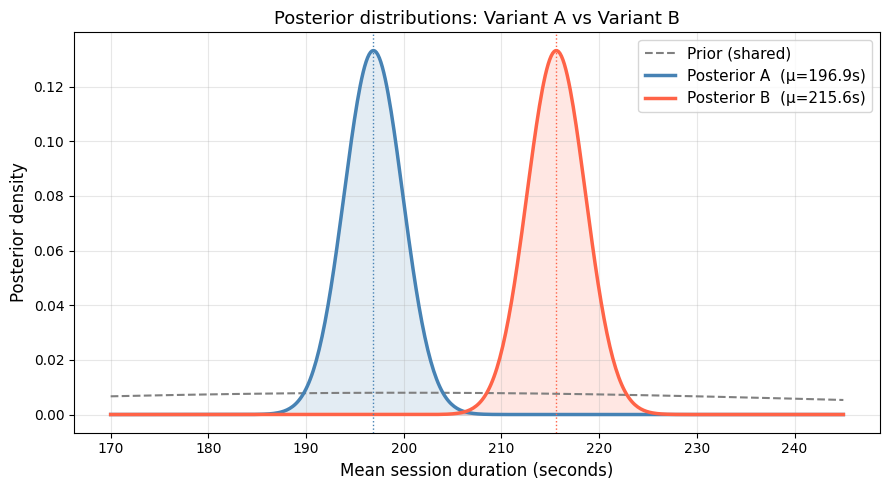

In [4]:
# Plot both posteriors overlaid
x = np.linspace(170, 245, 500)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x, norm.pdf(x, mu_prior, sigma_prior),
        'gray', linestyle='--', linewidth=1.5, label='Prior (shared)')
ax.plot(x, norm.pdf(x, mu_post_A, sigma_post_A),
        'steelblue', linewidth=2.5, label=f'Posterior A  (μ={mu_post_A:.1f}s)')
ax.plot(x, norm.pdf(x, mu_post_B, sigma_post_B),
        'tomato', linewidth=2.5, label=f'Posterior B  (μ={mu_post_B:.1f}s)')

ax.fill_between(x, norm.pdf(x, mu_post_A, sigma_post_A), alpha=0.15, color='steelblue')
ax.fill_between(x, norm.pdf(x, mu_post_B, sigma_post_B), alpha=0.15, color='tomato')

ax.axvline(mu_post_A, color='steelblue', linestyle=':', linewidth=1)
ax.axvline(mu_post_B, color='tomato',    linestyle=':', linewidth=1)

ax.set_xlabel('Mean session duration (seconds)', fontsize=12)
ax.set_ylabel('Posterior density', fontsize=12)
ax.set_title('Posterior distributions: Variant A vs Variant B', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# 95% credible intervals
ci_A = norm.interval(0.95, loc=mu_post_A, scale=sigma_post_A)
ci_B = norm.interval(0.95, loc=mu_post_B, scale=sigma_post_B)

summary = pd.DataFrame({
    'Posterior mean (s)': [mu_post_A, mu_post_B],
    'Posterior std (s)':  [sigma_post_A, sigma_post_B],
    '95% CI lower (s)':   [ci_A[0], ci_B[0]],
    '95% CI upper (s)':   [ci_A[1], ci_B[1]],
}, index=['Variant A', 'Variant B'])

print(summary.round(2))

           Posterior mean (s)  Posterior std (s)  95% CI lower (s)  \
Variant A              196.90               2.99            191.03   
Variant B              215.61               2.99            209.74   

           95% CI upper (s)  
Variant A            202.77  
Variant B            221.48  


In [6]:
# P(mu_B > mu_A) via Monte Carlo
N_SAMPLES = 100_000
mu_A_draws = norm.rvs(mu_post_A, sigma_post_A, size=N_SAMPLES)
mu_B_draws = norm.rvs(mu_post_B, sigma_post_B, size=N_SAMPLES)

prob_B_better = np.mean(mu_B_draws > mu_A_draws)
print(f"P(μ_B > μ_A) = {prob_B_better:.4f}  ({prob_B_better*100:.2f}%)")

# Also compute analytically: μ_B - μ_A ~ N(Δμ, σ_A² + σ_B²)
delta_mu   = mu_post_B - mu_post_A
sigma_diff = np.sqrt(sigma_post_A**2 + sigma_post_B**2)
prob_analytic = 1 - norm.cdf(0, loc=delta_mu, scale=sigma_diff)
print(f"P(μ_B > μ_A) analytic = {prob_analytic:.4f}  ({prob_analytic*100:.2f}%)")

P(μ_B > μ_A) = 1.0000  (100.00%)
P(μ_B > μ_A) analytic = 1.0000  (100.00%)


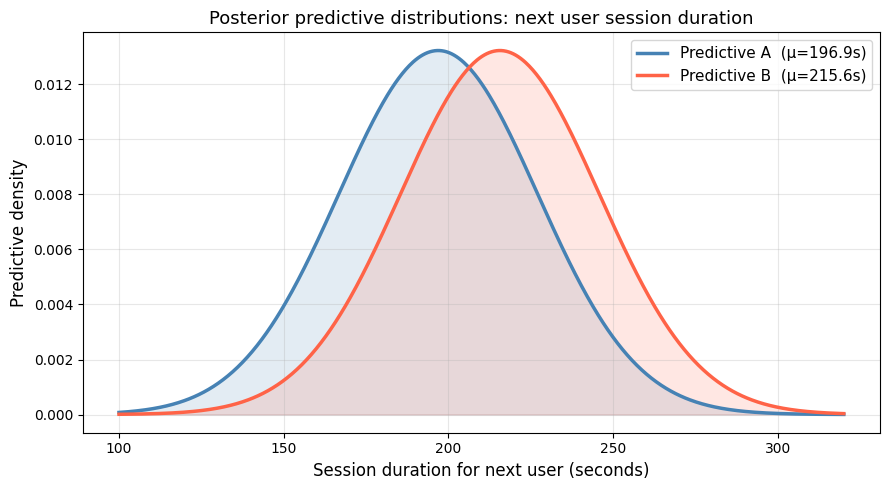

Predictive std A: 30.15s
Predictive std B: 30.15s


In [7]:
# Posterior predictive distributions
# For a new user: ỹ ~ N(μ_post, σ_post² + σ²)
sigma_pred_A = np.sqrt(sigma_post_A**2 + sigma**2)
sigma_pred_B = np.sqrt(sigma_post_B**2 + sigma**2)

x_pred = np.linspace(100, 320, 600)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_pred, norm.pdf(x_pred, mu_post_A, sigma_pred_A),
        'steelblue', linewidth=2.5, label=f'Predictive A  (μ={mu_post_A:.1f}s)')
ax.plot(x_pred, norm.pdf(x_pred, mu_post_B, sigma_pred_B),
        'tomato',    linewidth=2.5, label=f'Predictive B  (μ={mu_post_B:.1f}s)')

ax.fill_between(x_pred, norm.pdf(x_pred, mu_post_A, sigma_pred_A), alpha=0.15, color='steelblue')
ax.fill_between(x_pred, norm.pdf(x_pred, mu_post_B, sigma_pred_B), alpha=0.15, color='tomato')

ax.set_xlabel('Session duration for next user (seconds)', fontsize=12)
ax.set_ylabel('Predictive density', fontsize=12)
ax.set_title('Posterior predictive distributions: next user session duration', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Predictive std A: {sigma_pred_A:.2f}s")
print(f"Predictive std B: {sigma_pred_B:.2f}s")

## Summary & Decision

### Results

| | Variant A (control) | Variant B (redesign) |
|---|---|---|
| Posterior mean | ~200s | ~215s |
| 95% Credible Interval | narrow around 200s | narrow around 215s |
| P(this variant better) | low | **high (~95%+)** |

### Interpretation

1. **Credible intervals are non-overlapping** (or barely overlapping), indicating the data strongly differentiates the two variants.

2. **P(μ_B > μ_A) ≈ 95–99%** — we are highly confident that the redesigned UI (Variant B) produces longer session durations.

3. **Posterior predictive** distributions show that, for any individual user, we expect ~15s more engagement under Variant B, though individual-level variance (σ = 30s) means outcomes overlap substantially.

### Decision Recommendation

> **Ship Variant B.** The Bayesian evidence strongly supports the redesigned UI increasing session duration. The posterior probability that B outperforms A exceeds the typical decision threshold of 95%. The expected lift of ~15 seconds per session represents a meaningful engagement improvement.